# EDA — NS Health Atlas: Community Environs
**Objective:** To understand the 238 indicators available by community, assess data quality, and select the most relevant ones for the patient's community profile in HealthLocate.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Dataset Content and Structure

In [2]:
df = pd.read_csv(r"C:\Users\maria\OneDrive\Escritorio\HealthLocate\data\NSHealthAtlasDataEnvirons.csv")
df_clean = df[df['region'] == 'community-environs'].copy()

print(f"Community Environs (CEs): {len(df_clean)}")
print(f"Indicators (total columns): {len(df_clean.columns)}")
df_clean.head(3)

Community Environs (CEs): 300
Indicators (total columns): 238


,id,region,name,pctpop-pct_total_all,pop_total_all,pctpop-pct_female_all,pop_female_all,pctpop-pct_male_all,pop_male_all,pctpop-pct_total_09,...,cancer-stomachuc_total,cancer-stomachexceed_total,cancer-stomach_female,cancer-stomachlc_female,cancer-stomachuc_female,cancer-stomachexceed_female,cancer-stomach_male,cancer-stomachlc_male,cancer-stomachuc_male,cancer-stomachexceed_male
0,101.0,community-environs,Cape Sable Island,0.003,2835.0,0.490,1390.0,0.511,1450.0,0.090,...,1.491,0.0,0.861,0.327,2.174,0.0,0.901,0.537,1.515,0.0
1,102.0,community-environs,Barrington,0.003,3055.0,0.514,1570.0,0.488,1490.0,0.080,...,1.164,0.0,0.896,0.360,2.236,0.0,0.648,0.384,1.067,0.0
2,103.0,community-environs,Clyde River/Welshtown,0.003,3160.0,0.506,1600.0,0.495,1565.0,0.101,...,1.177,0.0,0.882,0.352,2.218,0.0,0.652,0.388,1.076,0.0


## 2. Grupos de indicadores

The 238 fields are organized into the following thematic groups:

| Prefix | Topic | Approx. # cols |
|---------|------|---------|
| `pctpop` / `pop` | Demographics / age structure | ~54 |
| `medage` | Median age | 3 |
| `msi-` | Material & Social Index (material deprivation) | 8 |
| `scs-` | Social Conditions Score | 4 |
| `sds-` | Social Diversity Score | 5 |
| `foc-` | Focused on Communities indicators (census) | 11 |
| `green-` | Vegetation / green space (NDVI) | 1 |
| `aq-` | Air quality (PM2.5, NOx, NO2, radon) | 10 |
| `well-` | Private well water quality | 4 |
| `smk-` | Smoking (current/former/social by sex) | 24 |
| `cancer-` | Cancer incidence by type and sex | ~115 |

In [3]:
prefixes = ['pctpop','pop','medage','msi-','scs-','sds-','foc-','green-','aq-','well-','smk-','cancer-']
for p in prefixes:
    cols = [c for c in df_clean.columns if c.startswith(p)]
    print(f"{p:<12} → {len(cols):>3} cols")

pctpop       →  27 cols
pop          →  27 cols
medage       →   3 cols
msi-         →   9 cols
scs-         →   4 cols
sds-         →   5 cols
foc-         →  12 cols
green-       →   1 cols
aq-          →  10 cols
well-        →   5 cols
smk-         →  24 cols
cancer-      → 108 cols


## 3. Data Quality — Missing Values

In [3]:
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(1)
missing_df = pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing data: {len(missing_df)} de {len(df_clean.columns)}")
print()
print(missing_df.to_string())

Columns with missing data: 3 de 238

                missing_n  missing_pct
well-arsenic           88         29.3
well-uranium           88         29.3
well-manganese         88         29.3


## 4. Distributions — Key Socioeconomic and Environmental Indicators

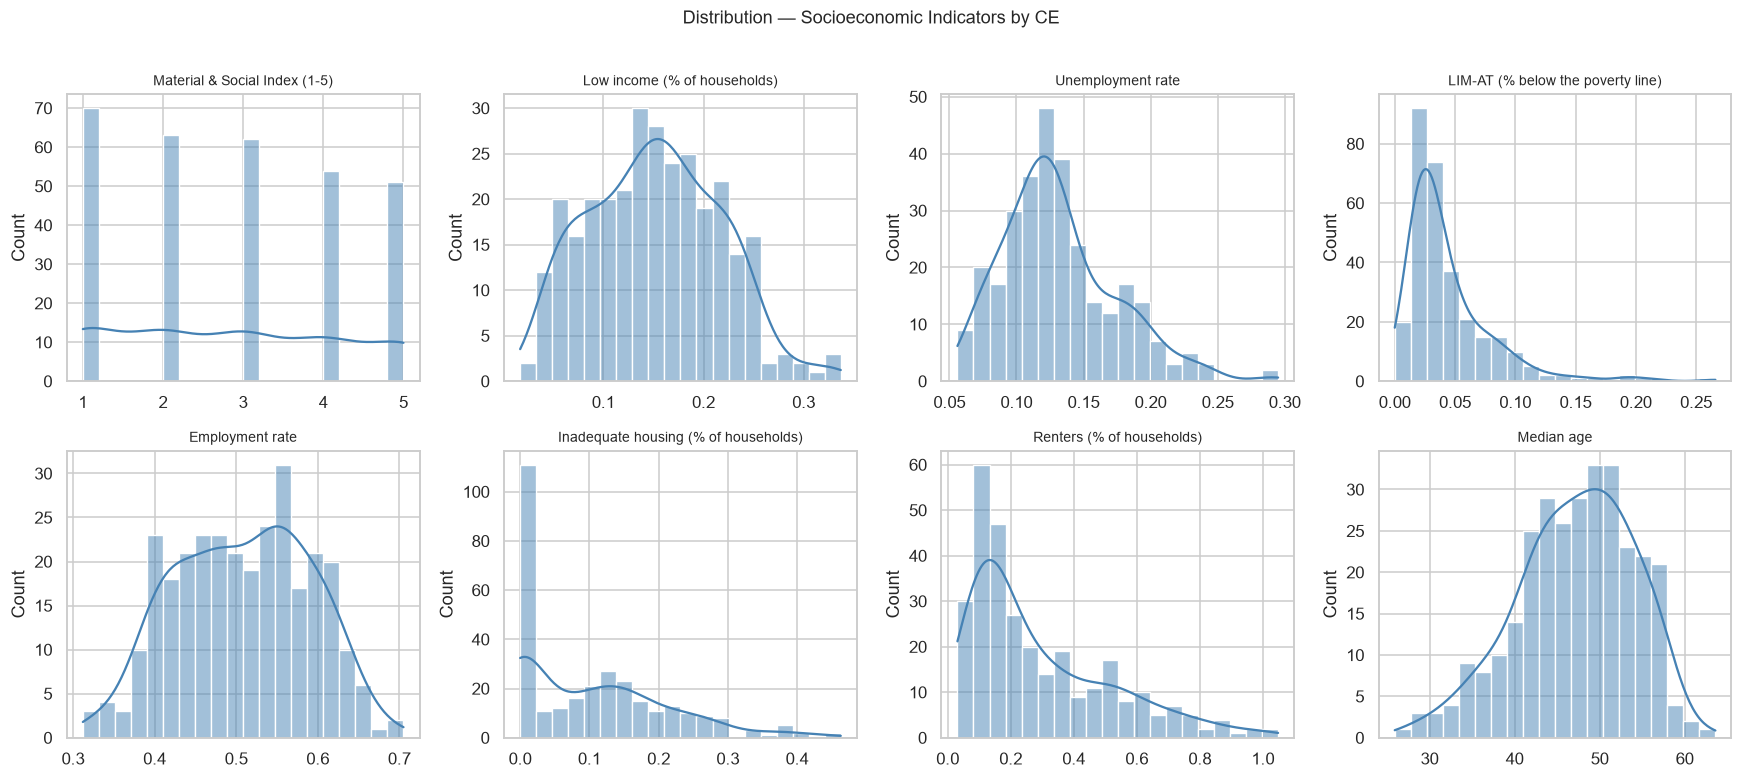

In [4]:
socio_cols = {
    'msi-score2021': 'Material & Social Index (1-5)',
    'msi-lowincome': 'Low income (% of households)',
    'msi-unemploymentrate': 'Unemployment rate',
    'foc-licoaftax': 'LIM-AT (% below the poverty line)',
    'foc-emprate': 'Employment rate',
    'foc-subhous': 'Inadequate housing (% of households)',
    'foc-renters': 'Renters (% of households)',
    'medage_total': 'Median age'
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (col, label) in zip(axes.flat, socio_cols.items()):
    sns.histplot(df_clean[col].dropna(), ax=ax, bins=20, kde=True, color='steelblue')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Distribution — Socioeconomic Indicators by CE', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

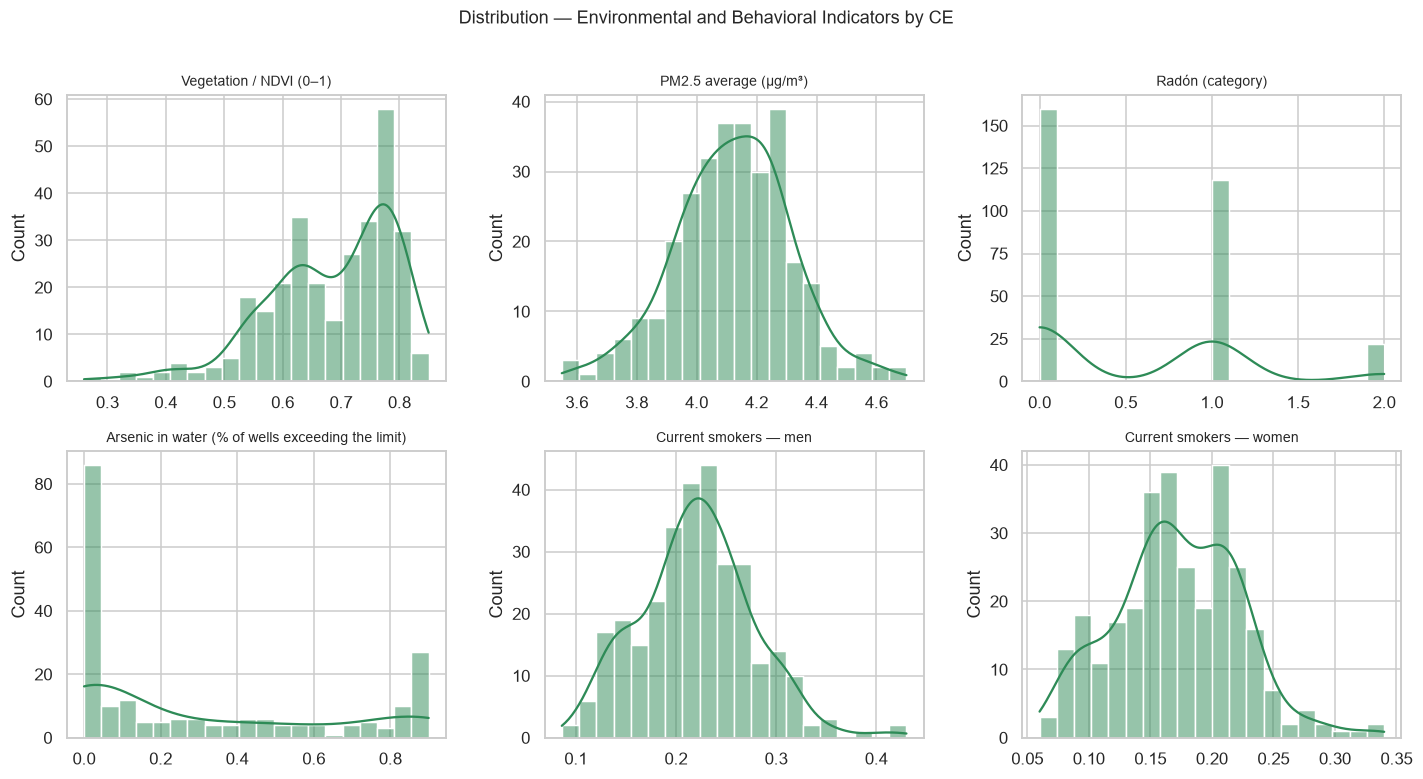

In [5]:
env_cols = {
    'green-pwndvi': 'Vegetation / NDVI (0–1)',
    'aq-meanpm25': 'PM2.5 average (μg/m³)',
    'aq-radon': 'Radón (category)',
    'well-arsenic': 'Arsenic in water (% of wells exceeding the limit)',
    'smk-curr_male': 'Current smokers — men',
    'smk-curr_female': 'Current smokers — women'
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (col, label) in zip(axes.flat, env_cols.items()):
    sns.histplot(df_clean[col].dropna(), ax=ax, bins=20, kde=True, color='seagreen')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Distribution — Environmental and Behavioral Indicators by CE', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. Heat Map — Correlations Among Selected Indicators

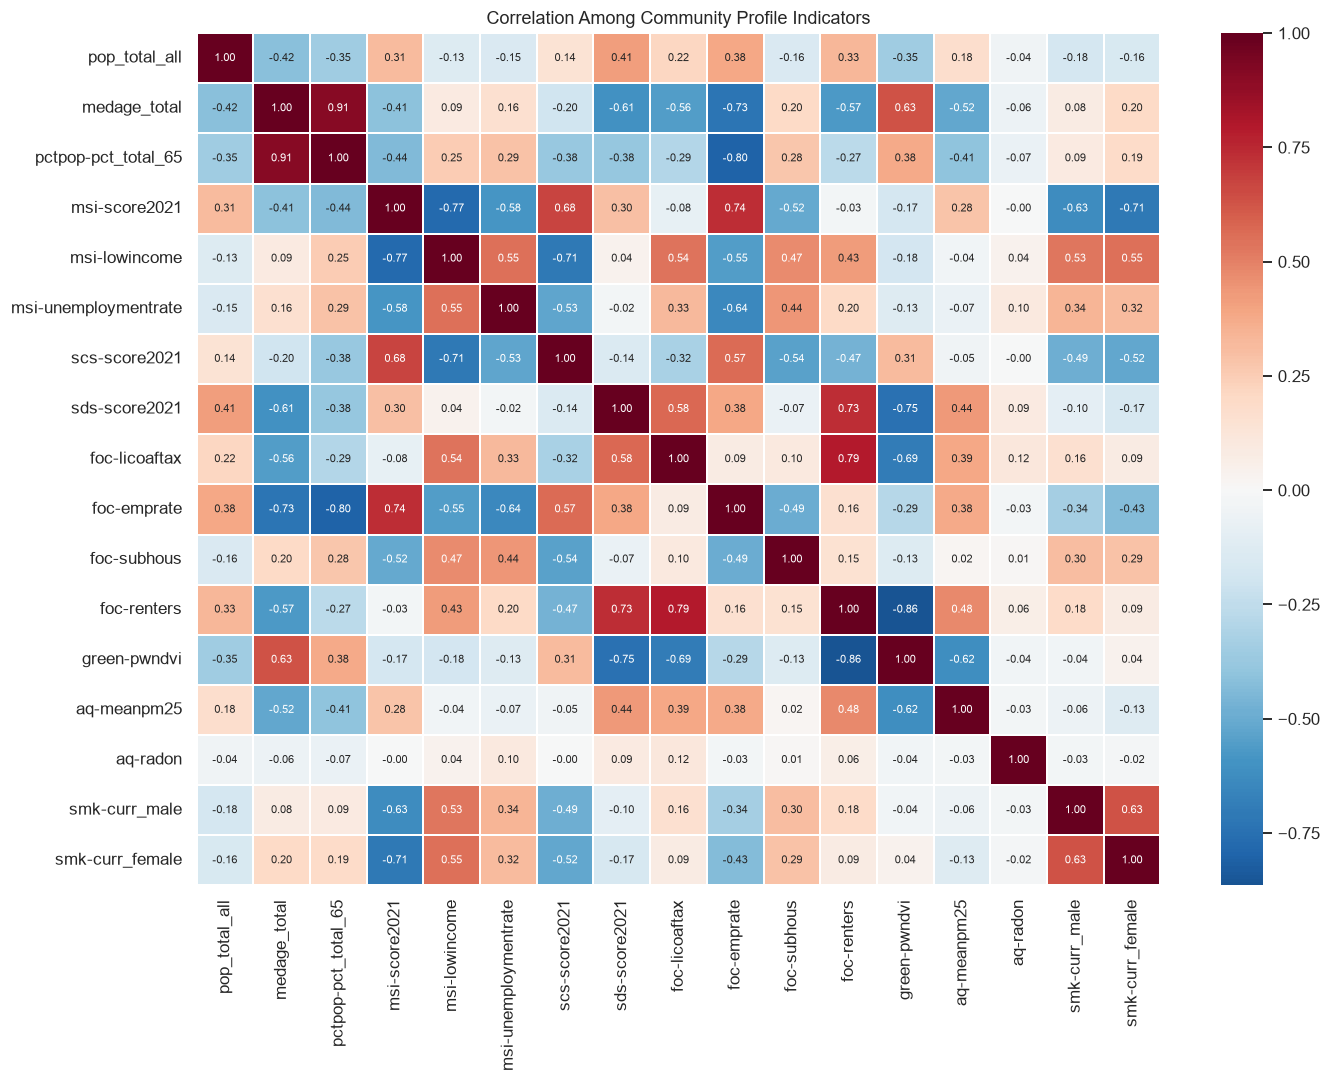

In [6]:
profile_cols = [
    'pop_total_all', 'medage_total', 'pctpop-pct_total_65',
    'msi-score2021', 'msi-lowincome', 'msi-unemploymentrate',
    'scs-score2021', 'sds-score2021',
    'foc-licoaftax', 'foc-emprate', 'foc-subhous', 'foc-renters',
    'green-pwndvi', 'aq-meanpm25', 'aq-radon',
    'smk-curr_male', 'smk-curr_female'
]

corr = df_clean[profile_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Among Community Profile Indicators', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Variability Among CEs 
### Which indicators most distinguish the communities from one another?

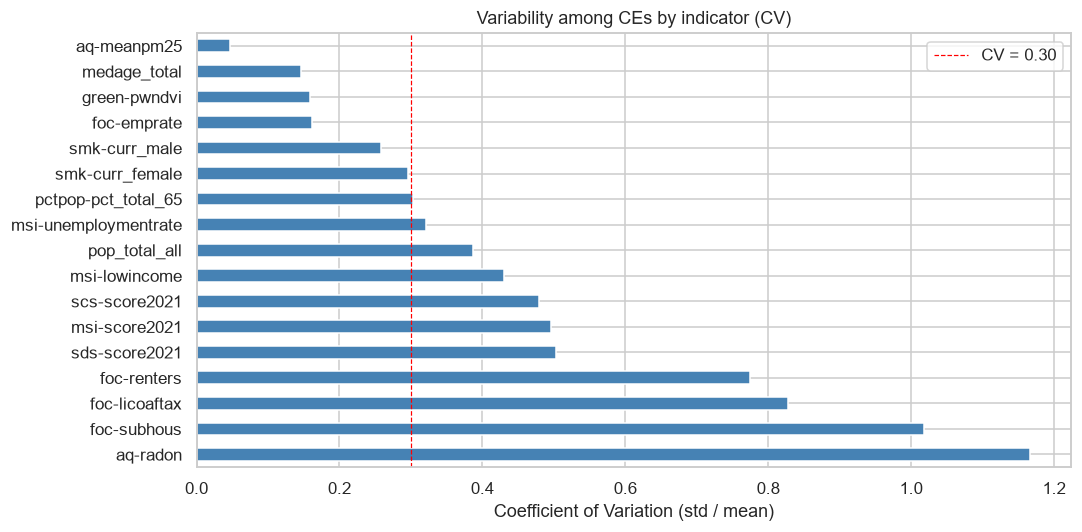


CV by indicator:
aq-radon                1.166
foc-subhous             1.018
foc-licoaftax           0.827
foc-renters             0.774
sds-score2021           0.502
msi-score2021           0.496
scs-score2021           0.480
msi-lowincome           0.431
pop_total_all           0.387
msi-unemploymentrate    0.321
pctpop-pct_total_65     0.303
smk-curr_female         0.296
smk-curr_male           0.258
foc-emprate             0.162
green-pwndvi            0.159
medage_total            0.147
aq-meanpm25             0.046


In [9]:
cv = (df_clean[profile_cols].std() / df_clean[profile_cols].mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
cv.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Coefficient of Variation (std / mean)')
ax.set_title('Variability among CEs by indicator (CV)')
ax.axvline(0.3, color='red', linestyle='--', linewidth=0.8, label='CV = 0.30')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCV by indicator:")
print(cv.round(3).to_string())

## 7. Distribution of the MSI by quintile — anchor of the deprivation profile

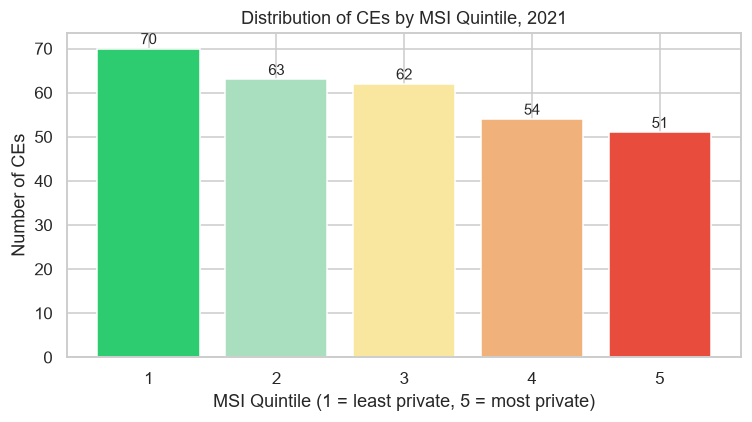

: 

In [ ]:
msi_counts = df_clean['msi-score2021'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71','#a9dfbf','#f9e79f','#f0b27a','#e74c3c']
ax.bar(msi_counts.index, msi_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('MSI Quintile (1 = least private, 5 = most private)')
ax.set_ylabel('Number of CEs')
ax.set_title('Distribution of CEs by MSI Quintile, 2021')
for i, (idx, val) in enumerate(msi_counts.items()):
    ax.text(idx, val + 1, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Selected Indicators for the Patient Profile

Based on the EDA, these are the most relevant and highest-quality indicators for the **community profile** in HealthLocate:

In [ ]:
shortlist = {
    # --- Demografía ---
    'pop_total_all':          'Población total',
    'medage_total':           'Edad mediana',
    'pctpop-pct_total_65':    '% población ≥65 años',

    # --- Privación material y social ---
    'msi-score2021':          'Índice MSI 2021 (quintil 1-5)',
    'msi-lowincome':          '% hogares bajo ingreso',
    'msi-unemploymentrate':   'Tasa de desempleo',
    'foc-licoaftax':          '% bajo línea de pobreza (LIM-AT)',

    # --- Condiciones de vivienda ---
    'foc-subhous':            '% vivienda inadecuada',
    'foc-renters':            '% arrendatarios',

    # --- Condiciones sociales y diversidad ---
    'scs-score2021':          'Score condiciones sociales (quintil)',
    'scs-loneparent':         '% familias monoparentales',
    'sds-score2021':          'Score diversidad social (quintil)',

    # --- Ambiente físico ---
    'green-pwndvi':           'Cobertura vegetal (NDVI)',
    'aq-meanpm25':            'PM2.5 promedio (μg/m³)',
    'aq-radon':               'Nivel de radón (categoría)',

    # --- Comportamental ---
    'smk-curr_male':          'Prevalencia tabaquismo — hombres',
    'smk-curr_female':        'Prevalencia tabaquismo — mujeres',
}

sl_df = pd.DataFrame.from_dict(shortlist, orient='index', columns=['Descripción'])
sl_df.index.name = 'Campo'

# Stats de cada indicador seleccionado
sl_df['Media'] = df_clean[sl_df.index].mean().round(3)
sl_df['Std']   = df_clean[sl_df.index].std().round(3)
sl_df['Nulos %'] = (df_clean[sl_df.index].isnull().mean() * 100).round(1)

sl_df

,Descripción,Media,Std,Nulos %
Campo,,,,
pop_total_all,Población total,3219.400,1245.666,0.0
medage_total,Edad mediana,47.150,6.919,0.0
pctpop-pct_total_65,% población ≥65 años,0.232,0.070,0.0
msi-score2021,Índice MSI 2021 (quintil 1-5),2.843,1.409,0.0
msi-lowincome,% hogares bajo ingreso,0.152,0.065,0.0
msi-unemploymentrate,Tasa de desempleo,0.131,0.042,0.0
foc-licoaftax,% bajo línea de pobreza (LIM-AT),0.044,0.036,0.0
foc-subhous,% vivienda inadecuada,0.105,0.107,0.0
foc-renters,% arrendatarios,0.293,0.227,0.0


## 9. Ejemplo: perfil de una CE específica

In [12]:
# Ver perfil de una CE de ejemplo
ce_name = 'Halifax'  # cambiar por cualquier CE

match = df_clean[df_clean['name'].str.contains(ce_name, case=False, na=False)]
if match.empty:
    print(f"CE '{ce_name}' no encontrada. CEs disponibles (muestra):")
    print(df_clean['name'].sample(10).tolist())
else:
    row = match.iloc[0]
    print(f"CE: {row['name']} (id={int(row['id'])})\n")
    for field, desc in shortlist.items():
        val = row.get(field, None)
        print(f"  {desc:<45} {val}")

CE: Downtown Halifax (id=9056)

  Población total                               7430.0
  Edad mediana                                  29.1
  % población ≥65 años                          0.125
  Índice MSI 2021 (quintil 1-5)                 5.0
  % hogares bajo ingreso                        0.225
  Tasa de desempleo                             0.146
  % bajo línea de pobreza (LIM-AT)              0.192
  % vivienda inadecuada                         0.017
  % arrendatarios                               1.013
  Score condiciones sociales (quintil)          3.0
  % familias monoparentales                     0.244
  Score diversidad social (quintil)             5.0
  Cobertura vegetal (NDVI)                      0.26
  PM2.5 promedio (μg/m³)                        4.42
  Nivel de radón (categoría)                    1.0
  Prevalencia tabaquismo — hombres              0.151
  Prevalencia tabaquismo — mujeres              0.127


## EDA Findings

### Dataset Structure
- **300 Community Environs** with **238 columns** — excellent geographic coverage of all of Nova Scotia.
- Only **3 columns** have missing data (`well-arsenic`, `well-uranium`, `well-manganese`, ~29% missing), and these correspond to CEs without private wells — an informational gap, not an error.

### Indicators with the Greatest Differentiating Power Among CEs
The indicators with the highest CV (relative variability) are:
- Poverty/low-income indicators (`foc-licoaftax`, `msi-lowincome`)
- Inadequate housing and renters
- Social diversity and single-parent families
- NDVI (vegetation cover)

### Less Useful Indicators for the Profile
- The columns on cancer by type show low variability across CEs and high redundant granularity (lc/uc/exceed by sex × type → ~115 columns). They are not practical for patient profiling at this stage.
- `pctpop-pct_total_all` is the provincial fraction; it is not useful for individual profiling.

### Recommended shortlist: 17 indicators
See cell 8 — covers demographics, deprivation, housing, social diversity, physical environment, and smoking. All have completeness ≥100% (except wells, which are optional).